# EDA — Maintenance prédictive (Vibrations)

**Notebook**: `EDA_Maintenance_Predictive.ipynb`

Ce notebook effectue une **analyse exploratoire complète (EDA)** sur un jeu de données de maintenance industrielle (pas 5 minutes). Il contient :

- Chargement et vérification des données
- Nettoyage / resampling
- Statistiques descriptives et distributions
- Visualisations temporelles (séries)
- Matrice de corrélations
- Création de la colonne `State_ISO` (OK / Warning / Alert / Critical)




In [24]:
# Configuration et imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import timedelta
import json
import pandas as pd
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype

#plt.style.use('sns')
#sns.set_context('talk')

# Chemin vers le JSON
JSON_PATH = "C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\Articles\\factories.json"
CSV_PATH = "C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\Articles\\smart_manufacturing_data.csv"
TIME_COL = 'timestamp'

# Vérifier que le fichier est présent
print('Fichier attendu :', CSV_PATH)
print('Présent ?', os.path.exists(CSV_PATH))

Fichier attendu : C:\Users\sarrj\Documents\Mes doc\Doc\Articles\smart_manufacturing_data.csv
Présent ? True


<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:18: SyntaxWarning: invalid escape sequence '\A'
C:\Users\sarrj\AppData\Local\Temp\ipykernel_6804\2703656195.py:17: SyntaxWarning: invalid escape sequence '\A'
  JSON_PATH = "C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\Articles\\factories.json"
C:\Users\sarrj\AppData\Local\Temp\ipykernel_6804\2703656195.py:18: SyntaxWarning: invalid escape sequence '\A'
  CSV_PATH = "C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\Articles\\smart_manufacturing_data.csv"


In [25]:
# Chargement des données
#data = json.load(open(JSON_PATH))
df = pd.read_csv(CSV_PATH)
#df = pd.DataFrame(data["feeds"])
df = df.sort_values(TIME_COL).reset_index(drop=True)

df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.set_index(TIME_COL)

print('Dimensions :', df.shape)
print('\nTypes :')
print(df.dtypes)

# Aperçu
print('\nAperçu (5 premières lignes) :')
display(df.head())

# Vérifier valeurs manquantes
print('\nValeurs manquantes par colonne :')
print(df.isna().sum())

# Statistiques globales
print('\nStatistiques descriptives :')
display(df.describe().T)


Dimensions : (100000, 12)

Types :
machine_id                    int64
temperature                 float64
vibration                   float64
humidity                    float64
pressure                    float64
energy_consumption          float64
machine_status                int64
anomaly_flag                  int64
predicted_remaining_life      int64
failure_type                 object
downtime_risk               float64
maintenance_required          int64
dtype: object

Aperçu (5 premières lignes) :


,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
timestamp,,,,,,,,,,,,
2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1



Valeurs manquantes par colonne :
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
machine_id,100000.0,25.499330,14.389439,1.00,13.0000,25.00,38.00,50.00
temperature,100000.0,75.015625,10.031884,35.55,68.2675,75.06,81.75,121.94
vibration,100000.0,50.012270,14.985444,-17.09,39.9700,49.96,60.10,113.80
humidity,100000.0,54.995401,14.437960,30.00,42.5200,54.98,67.50,80.00
pressure,100000.0,3.000405,1.152399,1.00,2.0000,3.01,4.00,5.00
energy_consumption,100000.0,2.747064,1.297865,0.50,1.6300,2.74,3.87,5.00
machine_status,100000.0,1.002050,0.446193,0.00,1.0000,1.00,1.00,2.00
anomaly_flag,100000.0,0.089160,0.284976,0.00,0.0000,0.00,0.00,1.00
predicted_remaining_life,100000.0,234.269160,150.063062,1.00,97.0000,230.00,365.00,499.00
downtime_risk,100000.0,0.089155,0.284961,0.00,0.0000,0.00,0.00,1.00


In [27]:
# Resampling & alignement temporel (pas = 5 minutes)

# passer en index temporel
if TIME_COL in df.columns:
    df = df.set_index(TIME_COL)
# vérifier le pas actuel
def infer_freq_and_resample(df_index):
    try:
        freq = pd.infer_freq(df_index)
    except Exception:
        freq = None
    return freq

freq = infer_freq_and_resample(df.index)
print('Fréquence détectée (pd.infer_freq):', freq)
#df = df[['temperature','vibration','humidity','pressure','energy_consumption','machine_status','anomaly_flag','predicted_remaining_life','downtime_risk','maintenance_required']]

# Convertir les colonnes numériques mal typées (ex: '71.94' en float)
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col]) 

# Resample to 5T to ensure regular grid
#df = df.resample('5min').mean()
print(df.columns)

df = df.groupby(['machine_id', 'machine_status','anomaly_flag','predicted_remaining_life','failure_type','downtime_risk','maintenance_required']).resample('5min').mean()

# Interpolation temporelle pour combler de petits trous
n_before = len(df)
df = df.interpolate(method='time')
print('Lignes après resample/interpolate :', len(df))

# Remettre Created_at comme colonne
if isinstance(df.index, pd.DatetimeIndex):
    df = df.reset_index().rename(columns={'index': TIME_COL})

display(df.head())
"""
"""

Fréquence détectée (pd.infer_freq): min
Index(['machine_id', 'temperature', 'vibration', 'humidity', 'pressure',
       'energy_consumption', 'machine_status', 'anomaly_flag',
       'predicted_remaining_life', 'failure_type', 'downtime_risk',
       'maintenance_required'],
      dtype='object')


ValueError: Only `method=linear` interpolation is supported on MultiIndexes.

In [ ]:
# Distribution des variables principales
features = [
    'Machine Temperature (C)',
    'Vibration Level (mm/s)',
    'Power Consumption (kW)',
    'Oil Level (%)',
    'Machine Efficiency (%)',
    'Downtime (mins)',
    'Maintenance Alerts (Count)'
]

plt.figure(figsize=(16,12))
for i, col in enumerate(features, 1):
    plt.subplot(4,2,i)
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, bins=50)
        plt.title(col)
    else:
        plt.text(0.1, 0.5, f'Colonne {col} non trouvée', fontsize=14)
        plt.axis('off')
plt.tight_layout()


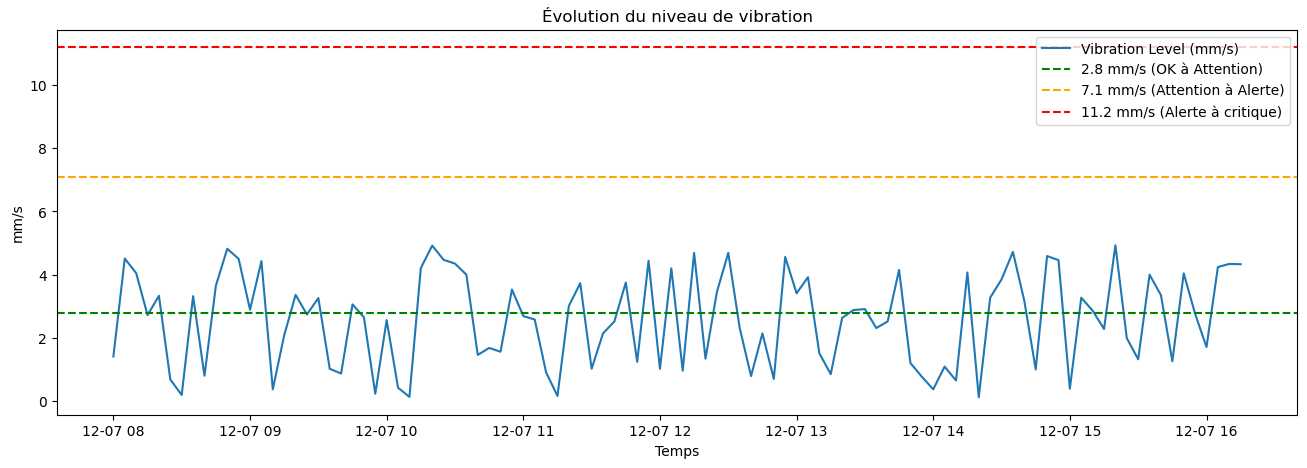

In [33]:
# Série temporelle — Vibration, avec seuils ISO simplifiés
if 'Vibration Level (mm/s)' in df.columns:
    plt.figure(figsize=(16,5))
    plt.plot(df[TIME_COL], df['Vibration Level (mm/s)'], label='Vibration Level (mm/s)')
    # Seuils simplifiés (à adapter selon la classe)
    plt.axhline(2.8, color='green', linestyle='--', label='2.8 mm/s (OK à Attention)')
    plt.axhline(7.1, color='orange', linestyle='--', label='7.1 mm/s (Attention à Alerte)')
    plt.axhline(11.2, color='red', linestyle='--', label='11.2 mm/s (Alerte à critique)')
    plt.legend()
    plt.title('Évolution du niveau de vibration')
    plt.xlabel('Temps')
    plt.ylabel('mm/s')
    plt.show()
else:
    print('Colonne Vibration Level (mm/s) non trouvée')


Colonnes numériques prises en compte : ['Machine Temperature (C)', 'Vibration Level (mm/s)', 'Power Consumption (kW)', 'Oil Level (%)', 'Machine Efficiency (%)', 'Downtime (mins)', 'Maintenance Alerts (Count)']


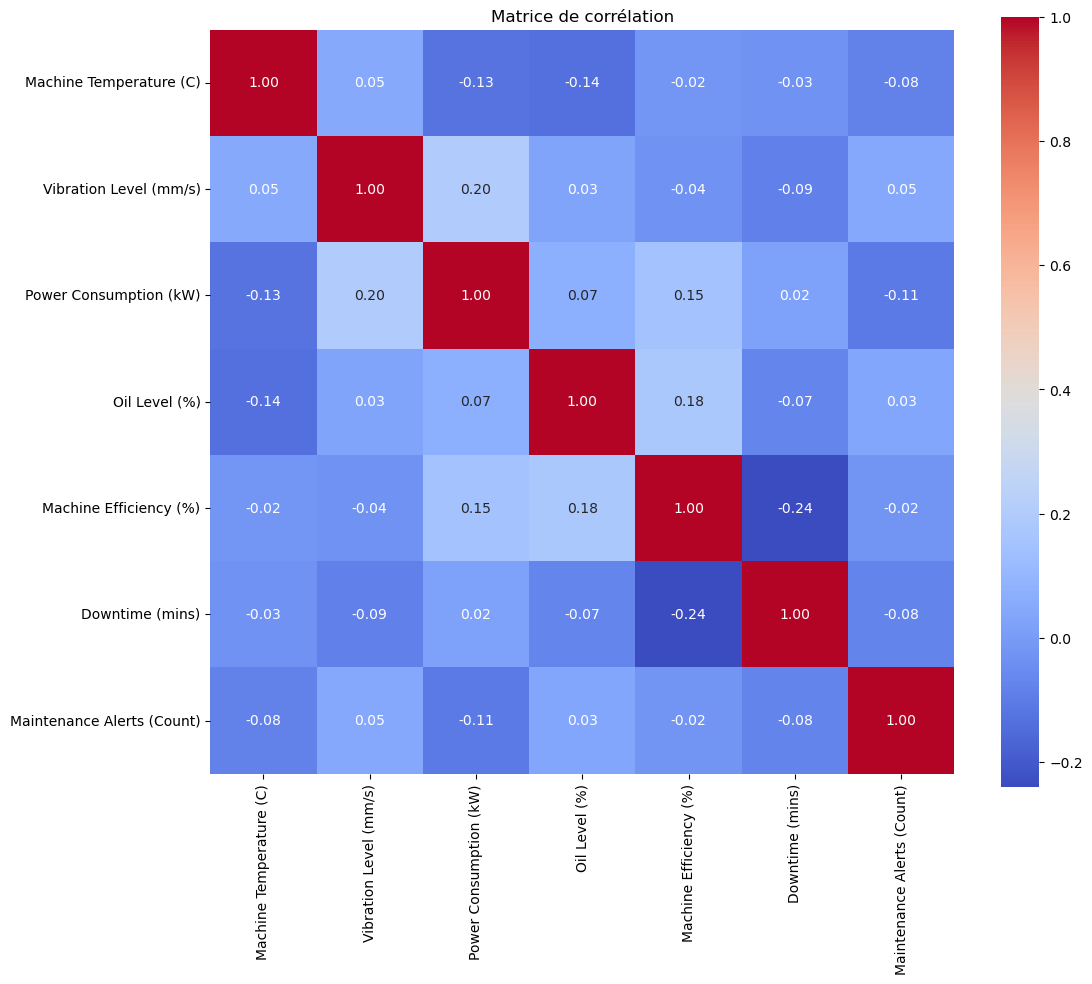

In [36]:
# Matrice de corrélation entre variables numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Colonnes numériques prises en compte :', numeric_cols[1:])

plt.figure(figsize=(12,10))
cm = df[numeric_cols[1:]].corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matrice de corrélation')
plt.show()


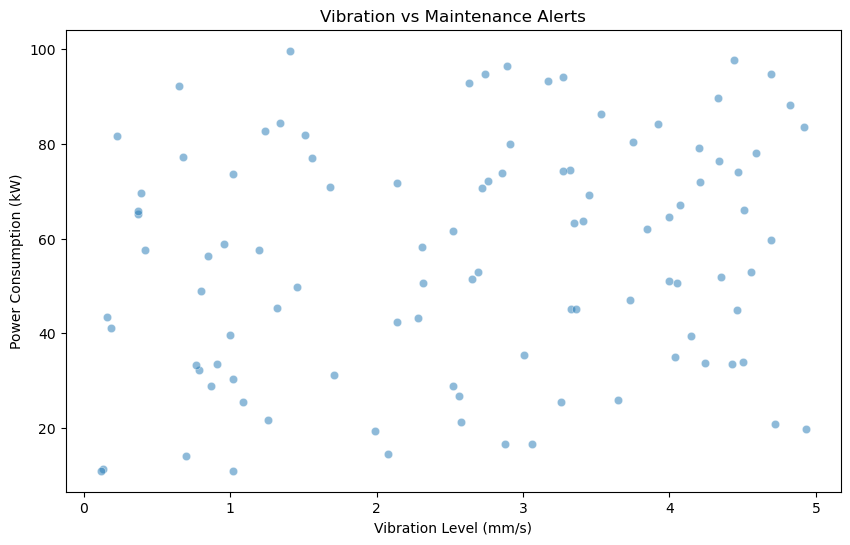

Répartition State_ISO :


State_ISO
OK           52
Attention    48
Name: count, dtype: int64

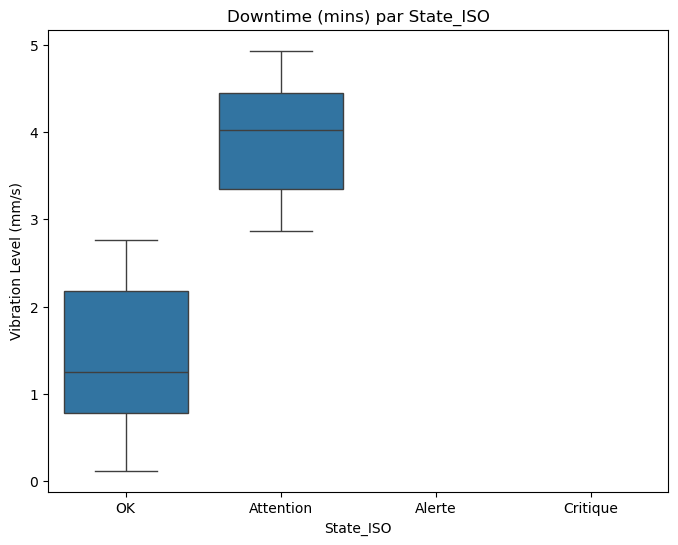

In [39]:
# Vibration vs Maintenance Alerts
if 'Vibration Level (mm/s)' in df.columns and 'Power Consumption (kW)' in df.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x='Vibration Level (mm/s)', y='Power Consumption (kW)', data=df, alpha=0.5)
    plt.title('Vibration vs Maintenance Alerts')
    plt.show()

# Création State_ISO selon seuils simplifiés
def iso_state(v):
    if pd.isna(v):
        return np.nan
    if v < 2.8:
        return 'OK'
    elif v < 7.1:
        return 'Attention'
    elif v < 11.2:
        return 'Alerte'
    else:
        return 'Critique'

if 'Vibration Level (mm/s)' in df.columns:
    df['State_ISO'] = df['Vibration Level (mm/s)'].apply(iso_state)
    print('Répartition State_ISO :')
    display(df['State_ISO'].value_counts(dropna=False))

    # Boxplot downtime by State_ISO if downtime exists
    if 'Downtime (mins)' in df.columns:
        plt.figure(figsize=(8,6))
        sns.boxplot(x='State_ISO', y='Vibration Level (mm/s)', data=df, order=['OK','Attention','Alerte','Critique'])
        plt.title('Downtime (mins) par State_ISO')
        plt.show()


In [41]:
# Exemple de création de features glissantes (rolling) pour la vibration
windows = [3, 6, 12, 24]
for w in windows:
    col_mean = f'vib_mean_{w}'
    col_std = f'vib_std_{w}'
    df[col_mean] = df['Vibration Level (mm/s)'].rolling(window=w, min_periods=1).mean()
    df[col_std] = df['Vibration Level (mm/s)'].rolling(window=w, min_periods=1).std().fillna(0)

# Afficher corrélation entre ces features et Maintenance Alerts
cols_check = [c for c in df.columns if 'vib_mean' in c or 'vib_std' in c]
print('Features rolling ajoutées :', cols_check)

if 'Downtime (mins)' in df.columns: #'Downtime (mins)' --- 'Maintenance Alerts (Count)'
    corr_vals = df[cols_check + ['Downtime (mins)']].corr()['Downtime (mins)'].sort_values(ascending=False)
    display(corr_vals)


Features rolling ajoutées : ['vib_mean_3', 'vib_std_3', 'vib_mean_6', 'vib_std_6', 'vib_mean_12', 'vib_std_12', 'vib_mean_24', 'vib_std_24']


Downtime (mins)    1.000000
vib_std_12         0.130974
vib_mean_24        0.122387
vib_std_24         0.116240
vib_mean_6         0.112412
vib_mean_12        0.063589
vib_mean_3         0.013875
vib_std_3          0.004925
vib_std_6         -0.063436
Name: Downtime (mins), dtype: float64

In [43]:
# Statistiques finales et sauvegarde d'un CSV traité pour modélisation
summary = {}
summary['n_rows'] = len(df)
summary['n_missing'] = df.isna().sum().sum()
summary['state_counts'] = df['State_ISO'].value_counts(dropna=False).to_dict() if 'State_ISO' in df.columns else {}
print('Résumé :')
print(summary)

# Sauvegarder un CSV pré-traité
OUT_CSV = 'vibrations_ana_ds.csv'
df.to_csv(OUT_CSV, index=False)
print('Fichier pré-traité sauvegardé :', OUT_CSV)


Résumé :
{'n_rows': 100, 'n_missing': np.int64(0), 'state_counts': {'OK': 52, 'Attention': 48}}
Fichier pré-traité sauvegardé : data_preprocessed_for_eda.csv
